<a href="https://colab.research.google.com/github/Thomas-Fabbris/MMIP-polimi/blob/main/Assignments/lecture_1_orthonormal_basis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook setup

Import the necessary modules, including `google.colab.drive` for accessing the required assets for the notebook (`croppedECG.mat`) from Google Drive

In [3]:
import numpy as np
import scipy
from matplotlib import pyplot as plt
from google.colab import drive  # pyright: ignore[reportMissingImports]

Mount your Google Drive folders, located at `/content/drive`, on the local runtime filesystem and define the root folder for the project

In [13]:
drive.mount('/content/drive', force_remount=True)
ROOT_FOLDER = '/content/drive/MyDrive/MMIP/data'

Mounted at /content/drive


Generate 1-D DCT basis
------------------------


In [5]:
M = 128                 # Signal Dimension
N = M                   # No. of atoms in the basis

# Matrix containing the DCT basis (a DCT function in each column)
D = np.zeros((M, N))
# Matrix containing the standard basis (a kronecker delta in each column)
DCT = np.zeros((M, N))

for k in range(M):
    DCT[:, k] = np.cos(k * np.pi * (2 * np.arange(0, M) + 1) / (2 * M))
    DCT[:, k] /= np.linalg.norm(DCT[:, k])

Display an atom of the dct basis

Text(0.5, 1.0, 'Element 25 from the DCT basis')

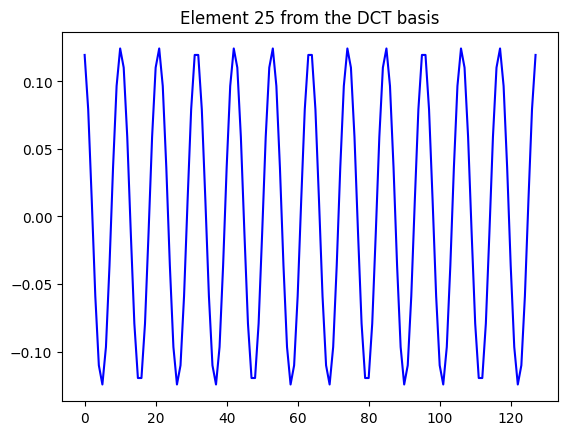

In [6]:
k = 24
plt.figure()
plt.plot(DCT[:, k], 'b')
plt.title(f'Element {k+1} from the DCT basis')

Check orthogonality

In [ ]:
is_DCT_orth = np.allclose(np.transpose(DCT) @ DCT, np.eye(M))
print(f'DCT dictionary is orthogonal: {is_DCT_orth}')

DCT dictionary is orthogonal: True


Display the basis in the matrix

Text(0.5, 1.0, 'DCT basis, atoms in the column')

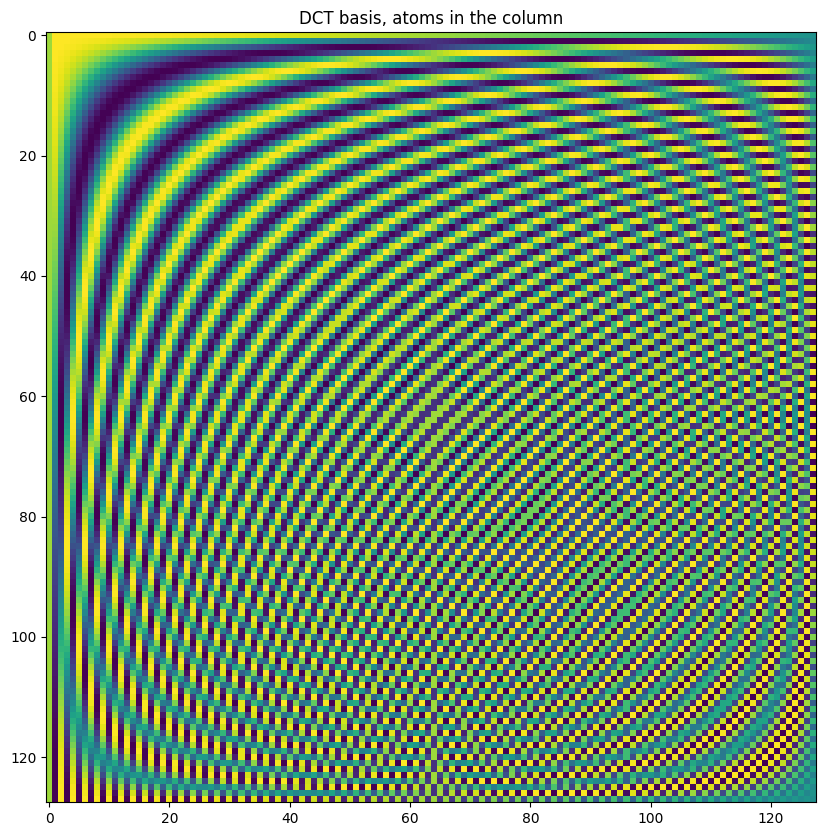

In [8]:
plt.figure(figsize=(10, 10))
plt.imshow(DCT)
plt.title('DCT basis, atoms in the column')

Generate 1-D DCT basis using the function `idct()`
---------------------------------------------
`idct()` is the inverse dct transform  
Stack this in the matrix `D`

In [9]:
for k in range(M):
    # Define the k-th atom
    a = np.zeros(M)
    a[k] = 1
    D[:, k] = scipy.fft.idct(a, norm='ortho')

Display the basis in the matrix

Text(0.5, 1.0, 'DCT basis, atoms in the column')

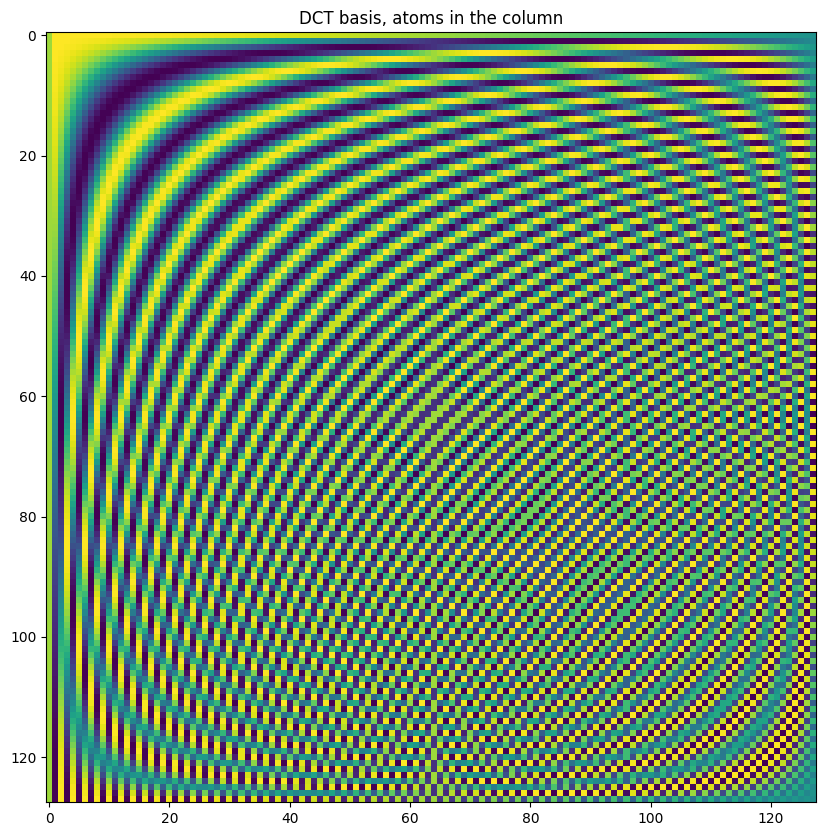

In [10]:
plt.figure(figsize=(10, 10))
plt.imshow(D)
plt.title('DCT basis, atoms in the column')

Check that `D` and `DCT` coincide

In [11]:
is_DCT_equal_D = np.allclose(D, DCT)
print(f'D and DCT are equal: {is_DCT_equal_D}')

D and DCT are equal: True


Analysis: compute the representation of an input ECG signal
-----------------------------------------------------------
Load few ECG signals to be processed

In [14]:
temp = scipy.io.loadmat(f'{ROOT_FOLDER}/croppedECG.mat')  # type: ignore
n_beats = 10
S = temp['S'][:, :n_beats]

X = np.zeros((M, n_beats))  # Matrix representation of S w.r.t D

Compute the representation coefficients

In [15]:
for i in range(n_beats):
    X[:, i] = np.transpose(D) @ S[:, i]

Display a signal and its representation coefficients

Text(0.5, 1.0, 'Coefficients w.r.t. DCT basis')

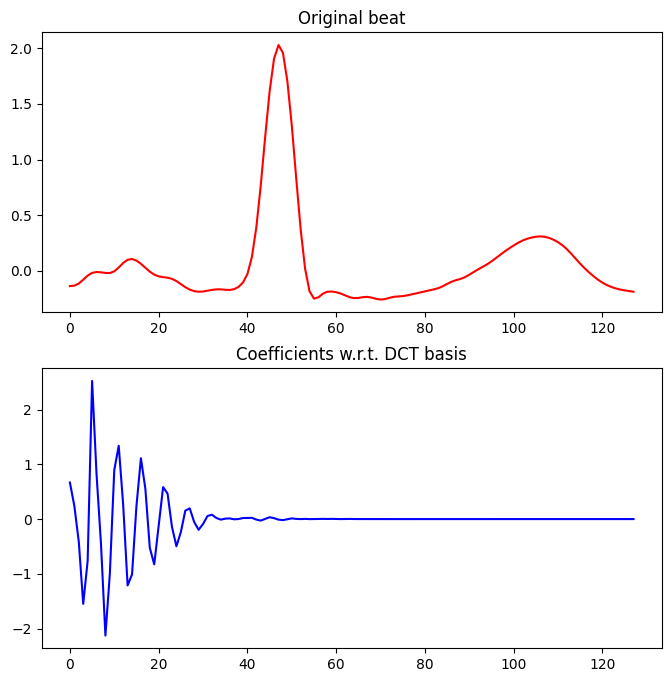

In [16]:
i = 5
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
ax1.plot(S[:, i], 'r')
ax1.set_title('Original beat')
ax2.plot(X[:, i], 'b')
ax2.set_title('Coefficients w.r.t. DCT basis')

Synthesis: reconstruct all the ECG signals from their representations
---------------------------------------------------------------------
Reconstruct the two signals, expressed w.r.t. the standard basis

In [17]:
S_hat_D = D @ np.transpose(D) @ S

Check if there is perfect reconstruction  

In [18]:
is_reconstruction_perfect = np.allclose(S_hat_D, S)
print(f'The reconstruction is perfect: {is_reconstruction_perfect}')

The reconstruction is perfect: True


The result is trivial because $\hat S_D = DD^TS$ and $DD^T = I_M$  since $D$ is 
orthonormal (the same applies to $DCT$)

Add noise to ECG data and inspect the representations
-----------------------------------------------------


In [19]:
sigma_noise = 0.1
S0 = S.copy()
S = S0 + sigma_noise * np.random.normal(size=S0.shape)

X = np.zeros((M, n_beats))  # Matrix representation of S w.r.t D

Compute the representation coefficients

In [20]:
for i in range(n_beats):
    X[:, i] = np.transpose(D) @ S[:, i]

Display a signal and its representation coefficients

Text(0.5, 1.0, 'Coefficients w.r.t. DCT basis')

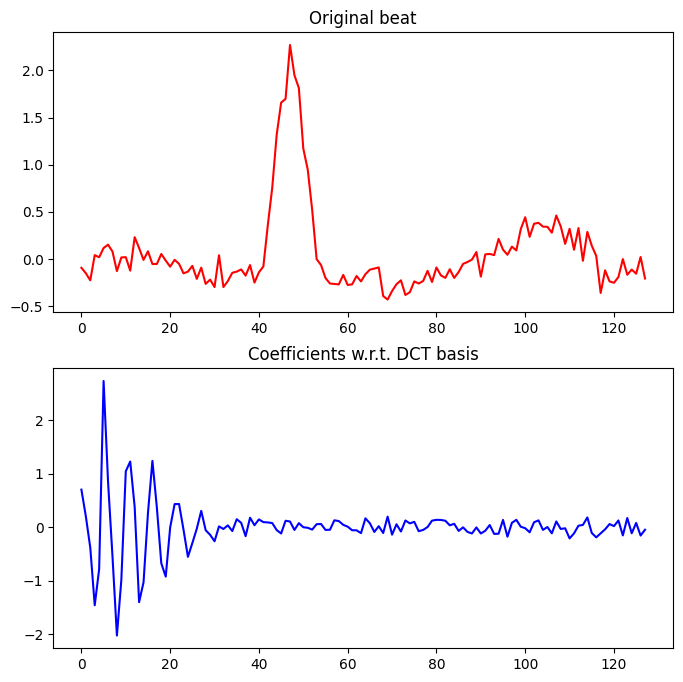

In [21]:
i = 5
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
ax1.plot(S[:, i], 'r')
ax1.set_title('Original beat')
ax2.plot(X[:, i], 'b')
ax2.set_title('Coefficients w.r.t. DCT basis')

Hard Thresholding
-----------------
Noise affects all the coefficients of the transformation, so keep only $L$ 
coefficients having largest magnitude  
For testing out the code with different values of the variable `L`, a slider was 
added

In [22]:
X_HT = np.zeros((M, n_beats))   # Matrix representation of S w.r.t. D
S_hat = np.zeros((M, n_beats))
L = 21  # @param {type: "slider", min: 1, max: 129, step: 1}

for i in range(n_beats):
    orig_signal = S0[:, i]
    noisy_signal = S[:, i]

    # Transform each signal separately (analysis)
    x = np.transpose(D) @ noisy_signal

    # Keep only the L largest coefficients in absolute value
    idx = np.argsort(np.abs(x))[-L:]
    x_thr = np.zeros_like(x)
    x_thr[idx] = x[idx]
    X_HT[:, i] = x_thr

    # Invert the transformation
    s_hat = D @ X_HT[:, i]

    S_hat[:, i] = s_hat

Display a signal

Text(0.5, 1.0, 'DCT coefficients')

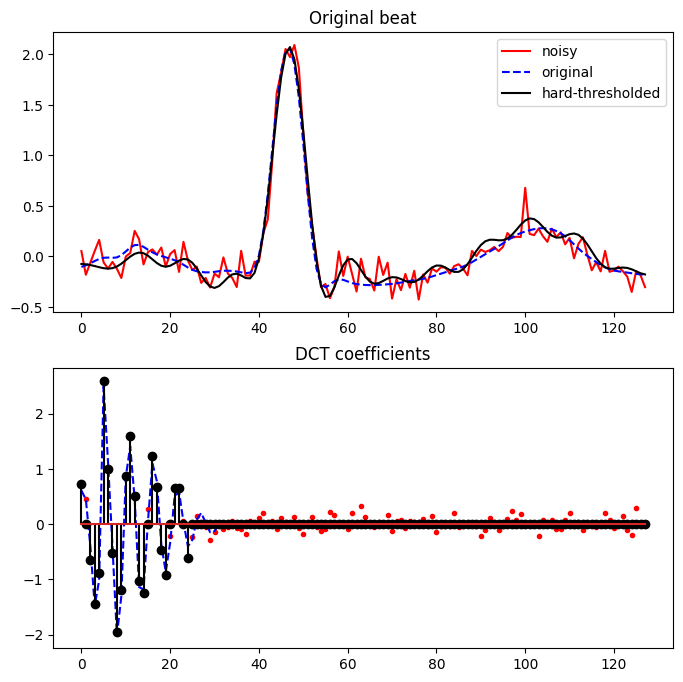

In [23]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
ax1.plot(S[:, i], 'r')
ax1.plot(S0[:, i], 'b--')
ax1.plot(S_hat[:, i], 'k')
ax1.legend(['noisy', 'original', 'hard-thresholded'])
ax1.set_title('Original beat')

ax2.plot(np.matmul(D.T, S[:, i]), 'r.')     # Coefficients of the noisy signal
# Coefficient of the noise-free signal
ax2.plot(np.matmul(D.T, S0[:, i]), 'b--')
ax2.stem(np.arange(M), X_HT[:, i], 'k')
ax2.set_title('DCT coefficients')

Compression
-----------
Compress a heartbeat using different value of $L$ and plot the mean squared 
error (MSE) corresponding to each $L$

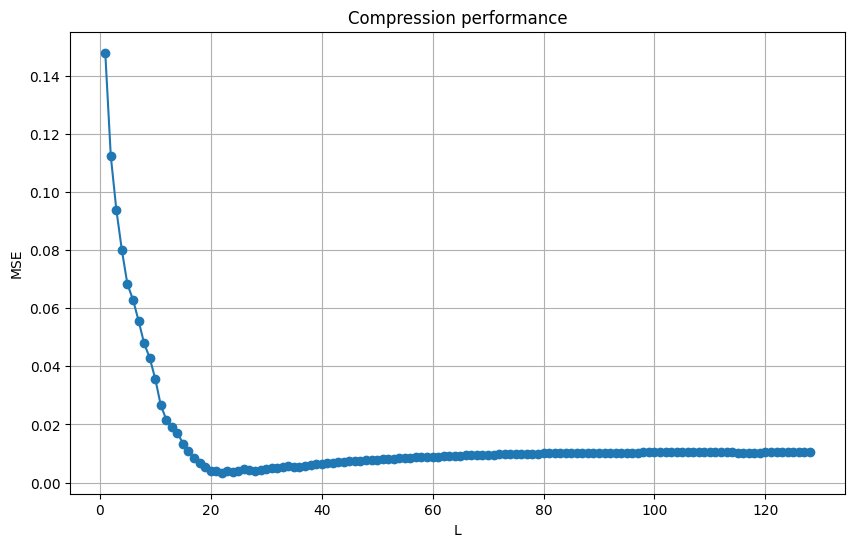

In [24]:
x_HT = np.zeros((M))    # Matrix of representations of S w.r.t. D
s_hat = np.zeros((M))

L_values = np.arange(1, M+1)
MSE_values = np.zeros(M)

orig_signal = S0[:, 0]
noisy_signal = S[:, 0]

for L in L_values:
    # Transform each signal separately (analysis)
    x = np.transpose(D) @ noisy_signal

    # Keep only the L largest coefficients in absolute value
    idx = np.argsort(np.abs(x))[-L:]
    x_HT[idx] = x[idx]

    # Invert the transformation
    s_hat = D @ x_HT

    mse = np.square(np.subtract(s_hat, orig_signal)).mean()
    MSE_values[L-1] = mse

plt.figure(figsize=(10, 6))
plt.plot(L_values, MSE_values, '-o')
plt.xlabel('L')
plt.ylabel('MSE')
plt.title('Compression performance')
plt.grid()